# Memorization fraction vs training iteration — SongUNet (Baptista et al. config), rescaled Matern, $n=2$

Analysis notebook: loads pre-computed results from `baptista_config_matern_n2.ipynb` and plots
memorization dynamics as a function of training epoch for four model sizes (model_channels =
4, 8, 16, 32).

**Source data**: `results/data/baptista_matern_n2/arm_{rescaled,unit}_c{4,8,16,32}_result.pt`

**What this shows**: Under the Baptista et al. arXiv:2501.15785 section 5.4 pipeline (SongUNet +
EDM preconditioner + deterministic Heun sampler), memorization onset depends on model capacity.
On rescaled Matern fields ($n_{train}=2$), C=4 (57K params) never memorizes, C=8 (223K) reaches
fraction 0.84, and C=16/C=32 (880K/3.5M) reach ~0.99. On unit-scale (unrescaled) fields, no
model memorizes — the geometry rescaling is necessary for memorization to appear.

In [1]:
import os, sys
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
results_dir = os.path.join(repo_root, 'results', 'data', 'baptista_matern_n2')
fig_dir = os.path.join(repo_root, 'results', 'figures')
os.makedirs(fig_dir, exist_ok=True)

# Load all 8 result files
rescaled = {}
unit = {}
for c in [4, 8, 16, 32]:
    rescaled[c] = torch.load(os.path.join(results_dir, f'arm_rescaled_c{c}_result.pt'),
                             map_location='cpu', weights_only=False)
    unit[c] = torch.load(os.path.join(results_dir, f'arm_unit_c{c}_result.pt'),
                         map_location='cpu', weights_only=False)

# Verify
for c in [4, 8, 16, 32]:
    print(f"C={c:>2}: rescaled {len(rescaled[c]['eval_log']):>2} evals, "
          f"{rescaled[c]['n_params']:>9,} params, "
          f"final frac={rescaled[c]['eval_log'][-1]['fraction']:.2f}  |  "
          f"unit {len(unit[c]['eval_log']):>2} evals, "
          f"final frac={unit[c]['eval_log'][-1]['fraction']:.2f}")

C= 4: rescaled 50 evals,    57,017 params, final frac=0.01  |  unit 50 evals, final frac=0.00
C= 8: rescaled 50 evals,   222,705 params, final frac=0.84  |  unit 50 evals, final frac=0.00
C=16: rescaled 50 evals,   880,097 params, final frac=0.99  |  unit 50 evals, final frac=0.01
C=32: rescaled 50 evals, 3,498,945 params, final frac=0.98  |  unit 50 evals, final frac=0.01


In [2]:
# Extract arrays for plotting
def extract_curves(runs):
    """Extract epoch, fraction, and nn_rel_median arrays from a dict of loaded results."""
    out = {}
    for c, r in sorted(runs.items()):
        log = r['eval_log']
        out[c] = dict(
            epochs=np.array([e['epoch'] for e in log]),
            opt_steps=np.array([e['opt_step'] for e in log]),
            fraction=np.array([e['fraction'] for e in log]),
            nn_rel_median=np.array([e['nn_rel_median'] for e in log]),
            n_params=r['n_params'],
        )
    return out

curves_rescaled = extract_curves(rescaled)
curves_unit = extract_curves(unit)

# Format parameter counts for legend
def fmt_params(n):
    if n >= 1_000_000:
        return f'{n/1_000_000:.1f}M'
    return f'{n/1_000:.0f}K'

for c in [4, 8, 16, 32]:
    cr = curves_rescaled[c]
    print(f"C={c:>2} ({fmt_params(cr['n_params']):>5} params): "
          f"epochs {cr['epochs'][0]:>5}-{cr['epochs'][-1]:>5}, "
          f"frac range [{cr['fraction'].min():.2f}, {cr['fraction'].max():.2f}], "
          f"nn_rel range [{cr['nn_rel_median'].min():.4f}, {cr['nn_rel_median'].max():.4f}]")

C= 4 (  57K params): epochs  1000-50000, frac range [0.00, 0.01], nn_rel range [0.7228, 4.9367]
C= 8 ( 223K params): epochs  1000-50000, frac range [0.00, 0.84], nn_rel range [0.0871, 4.9238]
C=16 ( 880K params): epochs  1000-50000, frac range [0.00, 0.99], nn_rel range [0.0347, 4.8958]
C=32 ( 3.5M params): epochs  1000-50000, frac range [0.00, 0.98], nn_rel range [0.0379, 4.8401]


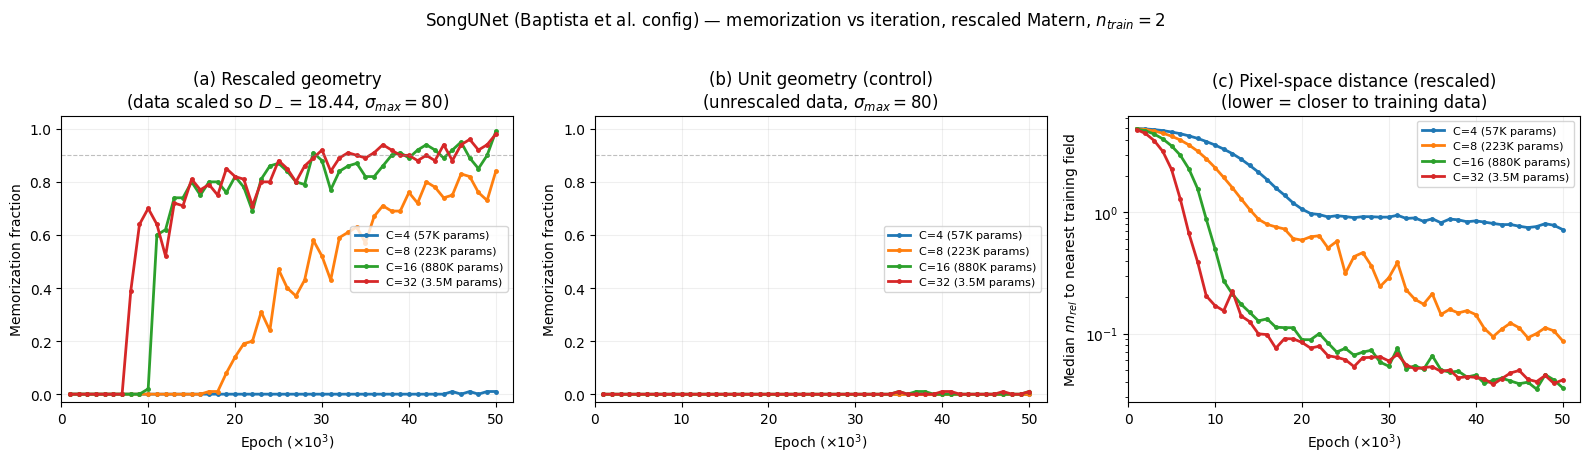

In [3]:
# --- Main figure: 3-panel plot ---
# Panel A: memorization fraction vs epoch (rescaled geometry)
# Panel B: memorization fraction vs epoch (unit geometry, control)
# Panel C: nn_rel_median vs epoch (rescaled, complementary pixel-space metric)

COLORS = {4: '#1f77b4', 8: '#ff7f0e', 16: '#2ca02c', 32: '#d62728'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Panel A: rescaled fraction ---
ax = axes[0]
for c in [4, 8, 16, 32]:
    cr = curves_rescaled[c]
    ax.plot(cr['epochs'] / 1000, cr['fraction'],
            color=COLORS[c], lw=2, marker='o', markersize=2.5,
            label=f'C={c} ({fmt_params(cr["n_params"])} params)')
ax.set_xlabel('Epoch ($\\times 10^3$)')
ax.set_ylabel('Memorization fraction')
ax.set_title('(a) Rescaled geometry\n(data scaled so $D_- = 18.44$, $\\sigma_{{max}} = 80$)')
ax.set_ylim(-0.03, 1.05)
ax.set_xlim(0, 52)
ax.axhline(0.9, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.legend(fontsize=8, loc='center right')
ax.grid(True, alpha=0.2)

# --- Panel B: unit fraction (control) ---
ax = axes[1]
for c in [4, 8, 16, 32]:
    cu = curves_unit[c]
    ax.plot(cu['epochs'] / 1000, cu['fraction'],
            color=COLORS[c], lw=2, marker='o', markersize=2.5,
            label=f'C={c} ({fmt_params(cu["n_params"])} params)')
ax.set_xlabel('Epoch ($\\times 10^3$)')
ax.set_ylabel('Memorization fraction')
ax.set_title('(b) Unit geometry (control)\n(unrescaled data, $\\sigma_{{max}} = 80$)')
ax.set_ylim(-0.03, 1.05)
ax.set_xlim(0, 52)
ax.axhline(0.9, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.legend(fontsize=8, loc='center right')
ax.grid(True, alpha=0.2)

# --- Panel C: nn_rel_median (rescaled) ---
ax = axes[2]
for c in [4, 8, 16, 32]:
    cr = curves_rescaled[c]
    ax.plot(cr['epochs'] / 1000, cr['nn_rel_median'],
            color=COLORS[c], lw=2, marker='o', markersize=2.5,
            label=f'C={c} ({fmt_params(cr["n_params"])} params)')
ax.set_xlabel('Epoch ($\\times 10^3$)')
ax.set_ylabel('Median $nn_{rel}$ to nearest training field')
ax.set_title('(c) Pixel-space distance (rescaled)\n(lower = closer to training data)')
ax.set_yscale('log')
ax.set_xlim(0, 52)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.2)

fig.suptitle('SongUNet (Baptista et al. config) — memorization vs iteration, '
             'rescaled Matern, $n_{train}=2$',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Saved to /Users/ishittaiyer/Desktop/research-diffusion/results/figures/songunet_memorization_vs_iteration.png


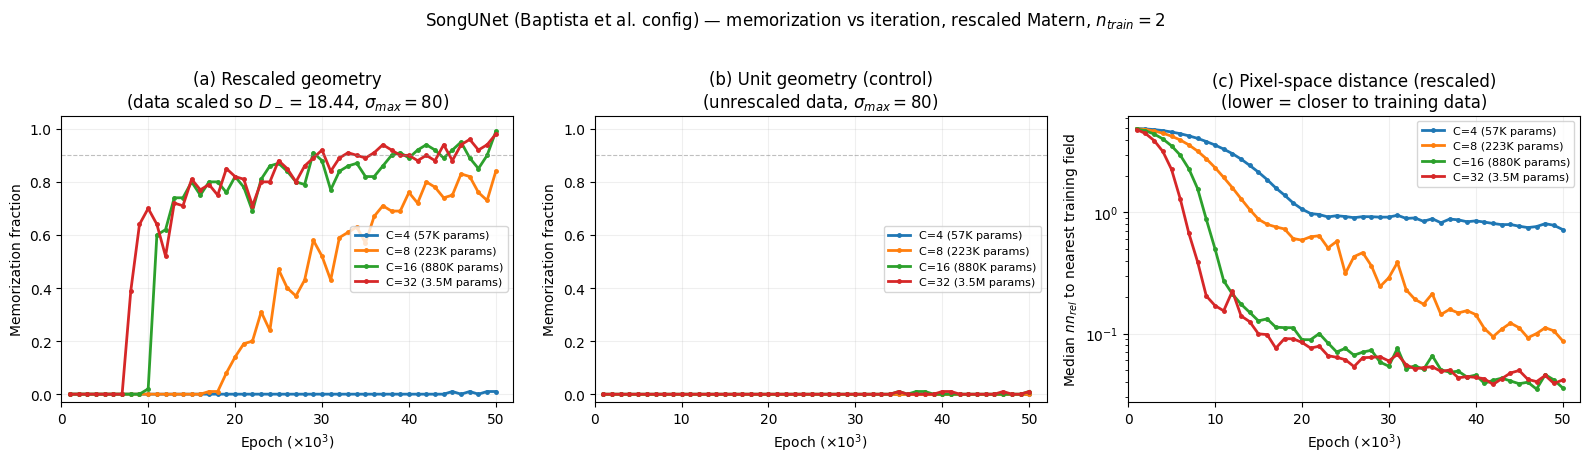

In [4]:
# --- Save figure ---
# Reproduce the same plot and save to disk at 300 dpi.

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel A: rescaled fraction
ax = axes[0]
for c in [4, 8, 16, 32]:
    cr = curves_rescaled[c]
    ax.plot(cr['epochs'] / 1000, cr['fraction'],
            color=COLORS[c], lw=2, marker='o', markersize=2.5,
            label=f'C={c} ({fmt_params(cr["n_params"])} params)')
ax.set_xlabel('Epoch ($\\times 10^3$)')
ax.set_ylabel('Memorization fraction')
ax.set_title('(a) Rescaled geometry\n(data scaled so $D_- = 18.44$, $\\sigma_{{max}} = 80$)')
ax.set_ylim(-0.03, 1.05)
ax.set_xlim(0, 52)
ax.axhline(0.9, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.legend(fontsize=8, loc='center right')
ax.grid(True, alpha=0.2)

# Panel B: unit fraction (control)
ax = axes[1]
for c in [4, 8, 16, 32]:
    cu = curves_unit[c]
    ax.plot(cu['epochs'] / 1000, cu['fraction'],
            color=COLORS[c], lw=2, marker='o', markersize=2.5,
            label=f'C={c} ({fmt_params(cu["n_params"])} params)')
ax.set_xlabel('Epoch ($\\times 10^3$)')
ax.set_ylabel('Memorization fraction')
ax.set_title('(b) Unit geometry (control)\n(unrescaled data, $\\sigma_{{max}} = 80$)')
ax.set_ylim(-0.03, 1.05)
ax.set_xlim(0, 52)
ax.axhline(0.9, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.legend(fontsize=8, loc='center right')
ax.grid(True, alpha=0.2)

# Panel C: nn_rel_median (rescaled)
ax = axes[2]
for c in [4, 8, 16, 32]:
    cr = curves_rescaled[c]
    ax.plot(cr['epochs'] / 1000, cr['nn_rel_median'],
            color=COLORS[c], lw=2, marker='o', markersize=2.5,
            label=f'C={c} ({fmt_params(cr["n_params"])} params)')
ax.set_xlabel('Epoch ($\\times 10^3$)')
ax.set_ylabel('Median $nn_{rel}$ to nearest training field')
ax.set_title('(c) Pixel-space distance (rescaled)\n(lower = closer to training data)')
ax.set_yscale('log')
ax.set_xlim(0, 52)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.2)

fig.suptitle('SongUNet (Baptista et al. config) — memorization vs iteration, '
             'rescaled Matern, $n_{train}=2$',
             fontsize=12, y=1.02)
plt.tight_layout()

save_path = os.path.join(fig_dir, 'songunet_memorization_vs_iteration.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved to {save_path}')
plt.show()